#### [ OpenCV 워크시트 - 문제 1 (따라하기) ]

- **미__션** : 아래 터널 곡선 도로 이미지 1장으로 요구사항을 모두 직접 구현하세요.
- **목__표** : 함수 이름과 파라미터는 스스로 떠올려야 합니다.
- **이미지** : tunnel.jpg  (흑백 터널 도로 - 점선 차선)


---
- **[요구사항]**

| 순서 | 작업 | 조건 |
|------|------|------|
| 1 | 그레이스케일 변환 | COLOR_BGR2GRAY |
| 2 | 가우시안 블러 | 커널 크기 자유 |
| 3 | ROI 추출 | 도로 영역만 남도록 직접 결정 |
| 4 | 캐니 엣지 | 임계값 자유, 블러 전/후 비교 출력 |

- **모폴로지 비교 (2x3 subplot)** 

| 위치 | 내용 |
|------|------|
| (1,1) | 캐니 엣지 원본 |
| (1,2) | 팽창 (Dilation) |
| (1,3) | 침식 (Erosion) |
| (2,1) | 열림 (Opening) |
| (2,2) | 닫힘 (Closing) |
| (2,3) | 열림 후 닫힘 (Opening -> Closing) |


- **핵심** 

- 닫힘 결과를 result_tunnel_lane.jpg 로 저장
- 중앙 50% ROI shape 출력
- 아래 질문에 주석으로 답하세요
    * Q1. 점선 차선이 닫힘(Closing) 후 어떻게 변했나요?
    * Q2. 열림 후 닫힘 순서와 닫힘 단독 적용의 차이는?
    * Q3. 이 이미지에서 HSV 마스크가 필요 없는 이유는?

In [3]:
import cv2
import numpy as np
import sys
sys.path.append(r'C:\Users\rosef\Documents\GitHub\KDT-14\[7]_CVISION')
from cv_utils import *

img = cv2.imread('../Data/images/tunnel.jpg')

In [24]:
# =============================================
# Part A - 전처리 파이프라인
# =============================================
# 1. 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. 가우시안 블러
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. ROI 추출 (도로 영역 직접 결정)
h, w = blur.shape[:2]
roi = blur[int(h*0.1):h, 0:w]

# 4. 캐니 엣지 (블러 전/후 비교)
edges_before = cv2.Canny(gray, 50, 150)
edges = cv2.Canny(roi, 50, 150)

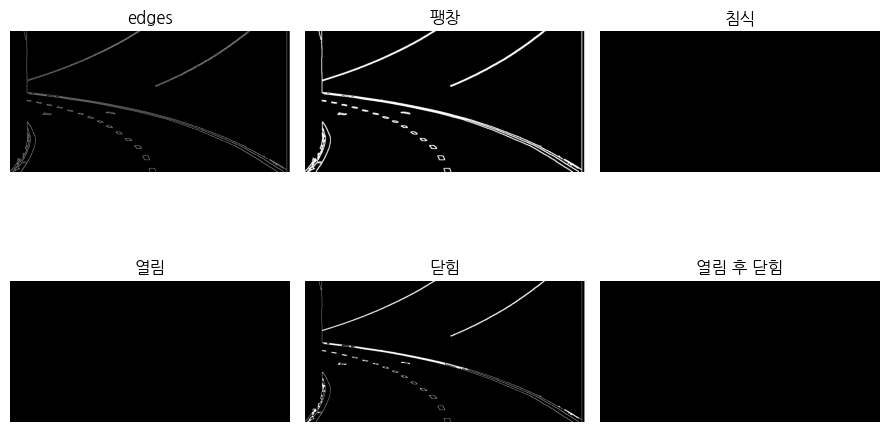

In [27]:
# =============================================
# Part B - 모폴로지 비교 (2x3 subplot)
# =============================================

# 구조 요소 생성
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# 팽창
dilated = cv2.dilate(edges, kernel, iterations=1)

# 침식
eroded = cv2.erode(edges, kernel, iterations=1)

# 열림
opening = cv2.morphologyEx(edges, cv2.MORPH_OPEN, kernel)

# 닫힘
closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# 열림 후 닫힘
op_cl = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

# 2x3 subplot 출력
printPlots(2,3, ['edges','팽창','침식','열림','닫힘','열림 후 닫힘'], [edges, dilated, eroded, opening, closing, op_cl], ['gray'])

In [ ]:
# =============================================
# Part C - 저장 & ROI & 질문 답변
# =============================================

# 닫힘 결과 저장
cv2.imwrite('result_tunnel_lane.jpg', closing)

# 중앙 50% ROI shape 출력
h, w = img.shape[:2]
center_roi = img[h//4 : h*3//4, w//4 : w*3//4]
print(f'중앙 50% ROI shape: {center_roi.shape}')

# Q1. 점선 차선이 닫힘(Closing) 후 어떻게 변했나요?
# A: ?

# Q2. 열림 후 닫힘 순서와 닫힘 단독 적용의 차이는?
# A: 노이즈가 더 깔끔하게 제거된 상태

# Q3. 이 이미지에서 HSV 마스크가 필요 없는 이유는?
# A: 흑백 이미지의 밝기 정보로 차선과 도로의 대비를 충분히 구분가능 함


중앙 50% ROI shape: (288, 514, 3)


---
## 힌트 (막힐 때만 확인)

<details>
<summary>힌트 1 - 전처리</summary>

```python
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur    = cv2.GaussianBlur(gray, (5, 5), 0)
h, w    = blur.shape[:2]
roi     = blur[int(h*0.3):h, 0:w]   # 하단 70% 사용
edges   = cv2.Canny(roi, 50, 150)
```
</details>

<details>
<summary>힌트 2 - 모폴로지</summary>

```python
kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
dilated  = cv2.dilate(edges,   kernel, iterations=1)
eroded   = cv2.erode(edges,    kernel, iterations=1)
opening  = cv2.morphologyEx(edges,   cv2.MORPH_OPEN,  kernel)
closing  = cv2.morphologyEx(edges,   cv2.MORPH_CLOSE, kernel)
op_cl    = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)
```
</details>

<details>
<summary>힌트 3 - 2x3 subplot</summary>

```python
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
items = [
    ('캐니 엣지', edges),
    ('팽창', dilated),
    ('침식', eroded),
    ('열림', opening),
    ('닫힘', closing),
    ('열림 후 닫힘', op_cl),
]
for ax, (t, im) in zip(axes.flat, items):
    ax.imshow(im, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()
```
</details>

<details>
<summary>힌트 4 - 중앙 50% ROI</summary>

```python
h, w = img.shape[:2]
center_roi = img[h//4 : h*3//4, w//4 : w*3//4]
print(f'중앙 ROI shape: {center_roi.shape}')
```
</details>

---
## 자가 채점

아래 셀을 실행하여 결과를 확인하세요.


In [15]:
import os
score, total = 0, 7

checks = [
    ('gray',    lambda: gray is not None and len(gray.shape)==2,
     '그레이스케일 변환'),
    ('edges',   lambda: edges is not None and len(edges.shape)==2,
     '캐니 엣지 검출'),
    ('dilated', lambda: dilated is not None,  '팽창 (Dilation)'),
    ('eroded',  lambda: eroded is not None,   '침식 (Erosion)'),
    ('opening', lambda: opening is not None,  '열림 (Opening)'),
    ('closing', lambda: closing is not None,  '닫힘 (Closing)'),
    ('op_cl',   lambda: op_cl is not None,    '열림 후 닫힘'),
]

for i, (var, check, desc) in enumerate(checks, 1):
    try:
        ok = check()
        mark = '통과' if ok else '미완'
        if ok: score += 1
    except:
        mark = '미완'
    print(f'[{i}/{total}] {mark} - {desc}')

if os.path.exists('result_tunnel_lane.jpg'):
    print('파일 저장 확인: result_tunnel_lane.jpg')
else:
    print('result_tunnel_lane.jpg 파일이 없습니다')

print(f'\n총점: {score} / {total}')
if score == total: print('완벽합니다!')
elif score >= 5:   print('거의 다 왔어요!')
else:              print('문제 1을 다시 확인해보세요')

[1/7] 통과 - 그레이스케일 변환
[2/7] 통과 - 캐니 엣지 검출
[3/7] 통과 - 팽창 (Dilation)
[4/7] 통과 - 침식 (Erosion)
[5/7] 통과 - 열림 (Opening)
[6/7] 통과 - 닫힘 (Closing)
[7/7] 통과 - 열림 후 닫힘
파일 저장 확인: result_tunnel_lane.jpg

총점: 7 / 7
완벽합니다!
